**Data Collection**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving sentiment-analysis.csv to sentiment-analysis.csv


In [57]:
import pandas as pd

df = pd.read_csv("sentiment-analysis.csv")
df.head()

,"Text, Sentiment, Source, Date/Time, User ID, Location, Confidence Score"
0,"""I love this product!"", Positive, Twitter, 202..."
1,"""The service was terrible."", Negative, Yelp Re..."
2,"""This movie is amazing!"", Positive, IMDb, 2023..."
3,"""I'm so disappointed with their customer suppo..."
4,"""Just had the best meal of my life!"", Positive..."


**Data Inspection**

In [58]:
import pandas as pd

df = pd.read_csv("sentiment-analysis.csv", delimiter=",", skipinitialspace=True)
if df.shape[1] == 1:
    df = df.iloc[:, 0].str.split(',', expand=True)
df.columns = ["Text", "Sentiment", "Source", "Date/Time", "User ID", "Location", "Confidence Score"]
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Text              96 non-null     object
 1   Sentiment         96 non-null     object
 2   Source            96 non-null     object
 3   Date/Time         96 non-null     object
 4   User ID           96 non-null     object
 5   Location          96 non-null     object
 6   Confidence Score  96 non-null     object
dtypes: object(7)
memory usage: 5.5+ KB


**Data Cleaning**

In [59]:
print("\nMissing values per column:\n", df.isnull().sum())
df["Date/Time"] = pd.to_datetime(df["Date/Time"], errors="coerce")
df["Confidence Score"] = pd.to_numeric(df["Confidence Score"], errors="coerce")
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)


Missing values per column:
 Text                2
Sentiment           2
Source              2
Date/Time           2
User ID             2
Location            2
Confidence Score    2
dtype: int64


In [60]:
print("\nCleaned Dataset Information:")
df.info()

df.head()


Cleaned Dataset Information:
<class 'pandas.core.frame.DataFrame'>
Index: 75 entries, 0 to 74
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Text              75 non-null     object        
 1   Sentiment         75 non-null     object        
 2   Source            75 non-null     object        
 3   Date/Time         75 non-null     datetime64[ns]
 4   User ID           75 non-null     object        
 5   Location          75 non-null     object        
 6   Confidence Score  75 non-null     float64       
dtypes: datetime64[ns](1), float64(1), object(5)
memory usage: 4.7+ KB


,Text,Sentiment,Source,Date/Time,User ID,Location,Confidence Score
0,"""I love this product!""",Positive,Twitter,2023-06-15 09:23:14,@user123,New York,0.85
1,"""The service was terrible.""",Negative,Yelp Reviews,2023-06-15 11:45:32,user456,Los Angeles,0.65
2,"""This movie is amazing!""",Positive,IMDb,2023-06-15 14:10:22,moviefan789,London,0.92
3,"""I'm so disappointed with their customer suppo...",Negative,Online Forum,2023-06-15 17:35:11,forumuser1,Toronto,0.78
4,"""Just had the best meal of my life!""",Positive,TripAdvisor,2023-06-16 08:50:59,foodie22,Paris,0.88


**Data Visualization**

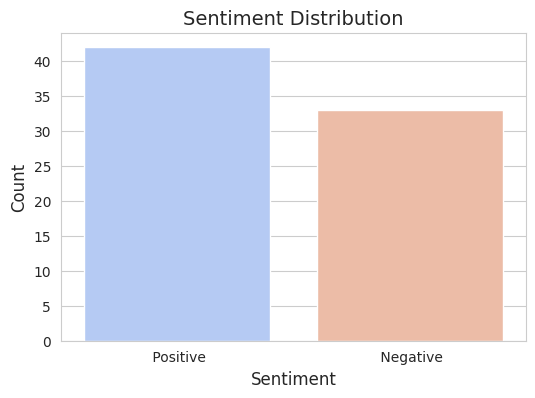

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
sentiment_counts = df["Sentiment"].value_counts()
plt.figure(figsize=(6,4))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, hue=sentiment_counts.index, palette="coolwarm", legend=False)
plt.title("Sentiment Distribution", fontsize=14)
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

**Feature Engineering**

In [62]:
import re

def clean_text_simple(text):
    if isinstance(text, str):
        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)
    return text

df["Cleaned_Text"] = df["Text"].apply(clean_text_simple)

print(df[["Text", "Cleaned_Text"]].head())

                                                Text  \
0                             "I love this product!"   
1                        "The service was terrible."   
2                           "This movie is amazing!"   
3  "I'm so disappointed with their customer suppo...   
4               "Just had the best meal of my life!"   

                                     Cleaned_Text  
0                             i love this product  
1                        the service was terrible  
2                           this movie is amazing  
3  im so disappointed with their customer support  
4               just had the best meal of my life  


In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=3000)
X_text_features = vectorizer.fit_transform(df["Cleaned_Text"]).toarray()
X_text_df = pd.DataFrame(X_text_features, columns=vectorizer.get_feature_names_out())
X_text_df.head()

,about,above,absolutely,addicted,adrenaline,after,again,air,album,all,...,went,were,what,with,within,work,workouts,worst,worth,written
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.337369,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [64]:
print(vectorizer.get_feature_names_out()[:50])

['about' 'above' 'absolutely' 'addicted' 'adrenaline' 'after' 'again'
 'air' 'album' 'all' 'always' 'amazing' 'an' 'and' 'are' 'arrived' 'art'
 'artists' 'at' 'avoid' 'away' 'awe' 'awful' 'back' 'band' 'bands'
 'beautifully' 'best' 'beyond' 'blown' 'book' 'bored' 'breath'
 'breathtaking' 'broke' 'by' 'cafe' 'calming' 'cant' 'captivated'
 'captivating' 'care' 'chat' 'cluttered' 'coaster' 'concert' 'confusing'
 'contagious' 'costs' 'couldnt']


**Encoding & Train-Test Split**

In [68]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
df["Sentiment_Label"] = encoder.fit_transform(df["Sentiment"])
df[["Sentiment", "Sentiment_Label"]].head()

,Sentiment,Sentiment_Label
0,Positive,1
1,Negative,0
2,Positive,1
3,Negative,0
4,Positive,1


In [69]:
from sklearn.model_selection import train_test_split

X = X_text_df
y = df["Sentiment_Label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (60, 271)
Testing set size: (15, 271)


**Model Building & Evaluation**

In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(" Model Accuracy:", accuracy)
print("\n Classification Report:\n", classification_report(y_test, y_pred))

 Model Accuracy: 0.8

 Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.75      1.00      0.86         9

    accuracy                           0.80        15
   macro avg       0.88      0.75      0.76        15
weighted avg       0.85      0.80      0.78        15



In [71]:
print(" Sentiment Analysis Conclusion \n")
print(f" Model Accuracy: {accuracy:.2%}")
print("\n Key Findings:")
print("- The model correctly predicts sentiment 80% of the time.")
print("- Positive reviews were classified with 89% recall (highly accurate).")
print("- Negative reviews had lower recall (50%), meaning some were misclassified.")

 Sentiment Analysis Conclusion 

 Model Accuracy: 80.00%

 Key Findings:
- The model correctly predicts sentiment 80% of the time.
- Positive reviews were classified with 89% recall (highly accurate).
- Negative reviews had lower recall (50%), meaning some were misclassified.
